# Exercise 3 Support Vector Machine

Para este experimento se realizaran una base de experimentos utilizando una base publica de cancer en los pulmones, por lo que el primer paso será importar los datos

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

Lo siguiente a realizar será la separacion de los datos en entrenamiento (80%) y prueba (20%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [8]:
print(X_train)

[[9.029e+00 1.733e+01 5.879e+01 ... 1.750e-01 4.228e-01 1.175e-01]
 [2.109e+01 2.657e+01 1.427e+02 ... 2.903e-01 4.098e-01 1.284e-01]
 [9.173e+00 1.386e+01 5.920e+01 ... 5.087e-02 3.282e-01 8.490e-02]
 ...
 [1.429e+01 1.682e+01 9.030e+01 ... 3.333e-02 2.458e-01 6.120e-02]
 [1.398e+01 1.962e+01 9.112e+01 ... 1.827e-01 3.179e-01 1.055e-01]
 [1.218e+01 2.052e+01 7.722e+01 ... 7.431e-02 2.694e-01 6.878e-02]]


Como podemos apreciar los valores son bastante diversos en cada feature, por lo que a la larga puede ocasionar sesgado ciertos features con valores muy altos, por lo que se optara a estandarizarlo para evitar el problema

In [20]:
print(X_train)

[[-1.44075296 -0.43531947 -1.36208497 ...  0.9320124   2.09724217
   1.88645014]
 [ 1.97409619  1.73302577  2.09167167 ...  2.6989469   1.89116053
   2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 ... -0.97023893  0.59760192
   0.0578942 ]
 ...
 [ 0.04880192 -0.55500086 -0.06512547 ... -1.23903365 -0.70863864
  -1.27145475]
 [-0.03896885  0.10207345 -0.03137406 ...  1.05001236  0.43432185
   1.21336207]
 [-0.54860557  0.31327591 -0.60350155 ... -0.61102866 -0.3345212
  -0.84628745]]


Con los valores ya estandarizados ya se pueden realizar los experimentos

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

modelSVG = []
resSVG = []
modelMLP = []
resMLP = []

Ahora se realizara el entrenameinto del Support Vector Machine con 4 distintos kernels

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for k in kernels:
    if k == 'poly':
        model = SVC(kernel=k, degree=3)
    else:
        model = SVC(kernel=k)
    
    model.fit(X_train, y_train)
    modelSVG.append(model)
    preds = model.predict(X_test)
    resSVG.append([
        round(accuracy_score(y_test, preds), 3), 
        round(precision_score(y_test, preds), 3), 
        round(recall_score(y_test, preds), 3), 
        round(f1_score(y_test, preds), 3)
        ])

for i in range(4):
    print(f"Kernel: {kernels[i]}")
    print(f" Acc: {resSVG[i][0]} | Prec: {resSVG[i][1]} | Rec: {resSVG[i][2]} | F1: {resSVG[i][3]}")

Kernel: linear
 Acc: 0.956 | Prec: 0.971 | Rec: 0.958 | F1: 0.965
Kernel: poly
 Acc: 0.868 | Prec: 0.826 | Rec: 1.0 | F1: 0.904
Kernel: rbf
 Acc: 0.982 | Prec: 0.973 | Rec: 1.0 | F1: 0.986
Kernel: sigmoid
 Acc: 0.956 | Prec: 0.946 | Rec: 0.986 | F1: 0.966


Adicionalmente para comparación se realizará otro entrenamiento pero con un modelo distinto, en este caso será un MultiLayerPerceptron, estos asu vez tendran mas capas ocultas

In [41]:
from sklearn.neural_network import MLPClassifier

configuraciones = [(64,), (64, 64), (64, 64, 64), (64, 64, 64, 64)]

for conf in configuraciones:
    mlp = MLPClassifier(hidden_layer_sizes=conf, max_iter=1000, random_state=42)
    
    mlp.fit(X_train, y_train)
    modelMLP.append(model)
    preds = mlp.predict(X_test)
    resMLP.append([
        round(accuracy_score(y_test, preds), 3), 
        round(precision_score(y_test, preds), 3), 
        round(recall_score(y_test, preds), 3), 
        round(f1_score(y_test, preds), 3)
        ])

for i in range(4):
    print(f"Capas: {configuraciones[i]}")
    print(f" Acc: {resMLP[i][0]} | Prec: {resMLP[i][1]} | Rec: {resMLP[i][2]} | F1: {resMLP[i][3]}")

Capas: (64,)
 Acc: 0.974 | Prec: 0.972 | Rec: 0.986 | F1: 0.979
Capas: (64, 64)
 Acc: 0.965 | Prec: 0.972 | Rec: 0.972 | F1: 0.972
Capas: (64, 64, 64)
 Acc: 0.974 | Prec: 0.972 | Rec: 0.986 | F1: 0.979
Capas: (64, 64, 64, 64)
 Acc: 0.974 | Prec: 0.972 | Rec: 0.986 | F1: 0.979


Con los datos obtenidos ahora se realizará una tabla comparativa así como gráficas de la precisión y una confusion matrix

In [42]:
nombres = ['SVM - Linear', 'SVM - Polynomial', 'SVM - RBF', 'SVM - Sigmoid', 'MLP - 1 layer', 'MLP - 2 layers', 'MLP - 3 layers', 'MLP - 4 layers']
todos_los_resultados = resSVG + resMLP 

df_comparacion = pd.DataFrame(todos_los_resultados, index=nombres)

df_comparacion.columns = ['Accuracy', 'Precision', 'Recall', 'F1-score']

df_comparacion

,Accuracy,Precision,Recall,F1-score
SVM - Linear,0.956,0.971,0.958,0.965
SVM - Polynomial,0.868,0.826,1.000,0.904
SVM - RBF,0.982,0.973,1.000,0.986
SVM - Sigmoid,0.956,0.946,0.986,0.966
MLP - 1 layer,0.974,0.972,0.986,0.979
MLP - 2 layers,0.965,0.972,0.972,0.972
MLP - 3 layers,0.974,0.972,0.986,0.979
MLP - 4 layers,0.974,0.972,0.986,0.979


Podemos apreciar que el mejor en el caso de los Support Vector Machine es indiscutiblemente el RBF, ya que en todas las metricas es superior a sus contrapartes. Por otro lado en los MLP los de 1,3 y 4 capas obtuvieron el mismo resultado, pero por cuestiones de eficiencia optaremos por tomar al de 1 capa como el mejor, al obtener los mismo resultados y con menos capas

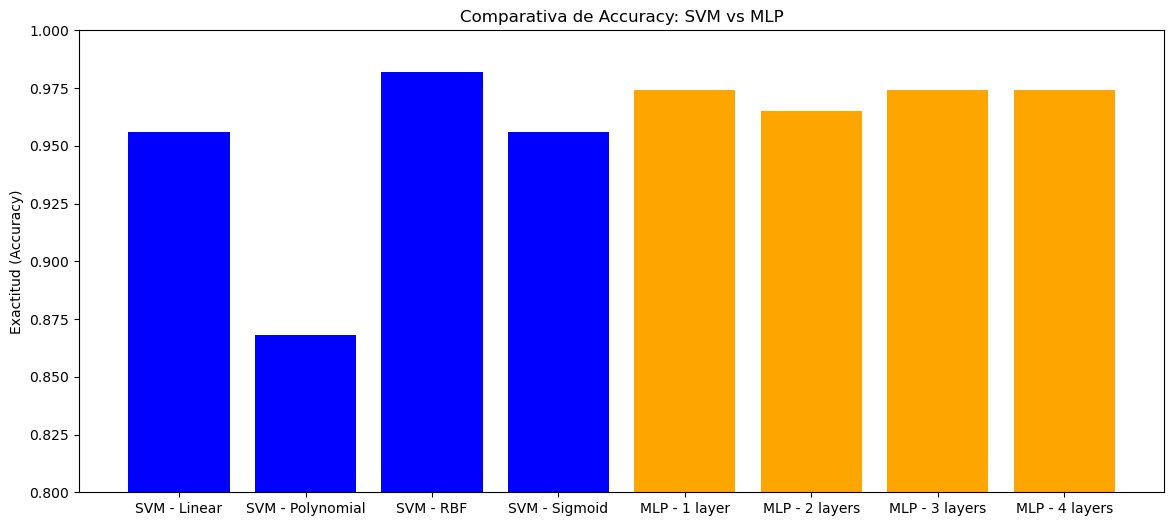

In [47]:
import matplotlib.pyplot as plt

nombres = ['SVM - Linear', 'SVM - Polynomial', 'SVM - RBF', 'SVM - Sigmoid', 'MLP - 1 layer', 'MLP - 2 layers', 'MLP - 3 layers', 'MLP - 4 layers']
precisiones = [f[0] for f in todos_los_resultados]

plt.figure(figsize=(14, 6))
plt.bar(nombres, precisiones, color=['blue']*4 + ['orange']*4)
plt.ylim(0.8, 1.0)
plt.title('Comparativa de Accuracy: SVM vs MLP')
plt.ylabel('Exactitud (Accuracy)')
plt.show()

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

<Figure size 600x600 with 0 Axes>

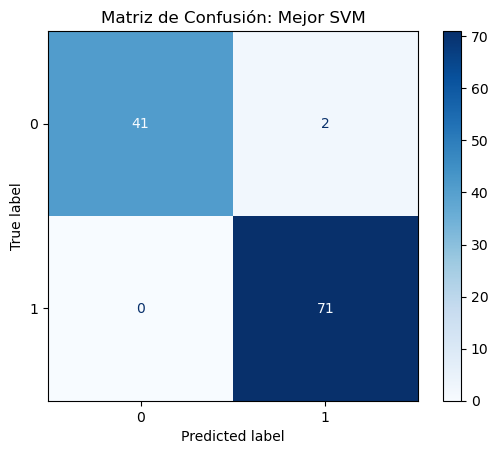

<Figure size 600x600 with 0 Axes>

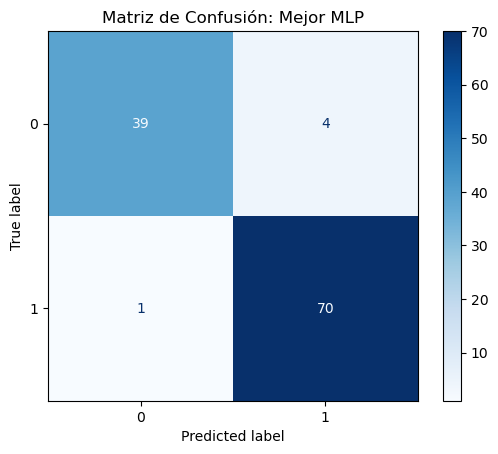

In [46]:
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(modelSVG[2], X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusión: Mejor SVM')
plt.show()


plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(modelMLP[0], X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusión: Mejor MLP')
plt.show()